In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler # Import StandardScaler

In [41]:
data = pd.read_csv('/content/penguins.csv')
data


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [42]:
data.isna().sum()

,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,9


In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'].astype(str))
data

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
3,NaN,NaN,NaN,NaN,3
4,36.7,19.3,193.0,3450.0,1
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,3
340,46.8,14.3,215.0,4850.0,1
341,50.4,15.7,222.0,5750.0,2
342,45.2,14.8,212.0,5200.0,1


In [44]:
data.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

In [45]:
data["culmen_length_mm"].fillna(data["culmen_length_mm"].mean(), inplace = True)
data["culmen_depth_mm"].fillna(data["culmen_depth_mm"].mean(), inplace = True)
data["flipper_length_mm"].fillna(data["flipper_length_mm"].mean(), inplace = True)
data["body_mass_g"].fillna(data["body_mass_g"].mean(), inplace = True)
data


/tmp/ipykernel_1601/2172085281.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["culmen_length_mm"].fillna(data["culmen_length_mm"].mean(), inplace = True)
/tmp/ipykernel_1601/2172085281.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.10000,18.70000,181.00000,3750.000000,2
1,39.50000,17.40000,186.00000,3800.000000,1
2,40.30000,18.00000,195.00000,3250.000000,1
3,43.92193,17.15117,214.01462,4201.754386,3
4,36.70000,19.30000,193.00000,3450.000000,1
...,...,...,...,...,...
339,43.92193,17.15117,214.01462,4201.754386,3
340,46.80000,14.30000,215.00000,4850.000000,1
341,50.40000,15.70000,222.00000,5750.000000,2
342,45.20000,14.80000,212.00000,5200.000000,1


In [46]:
data.isna().sum()

# --- New code for Feature Scaling ---
scaler = StandardScaler()

# Fit and transform all columns in 'data' as they are used for clustering.
data_scaled_array = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled_array, columns=data.columns)

print("Scaled Data Head:")
display(data_scaled.head())

Scaled Data Head:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,-8.870812e-01,7.877425e-01,-0.127263,-0.565789,0.829651
1,-8.134940e-01,1.265563e-01,-0.107990,-0.503168,-0.976677
2,-6.663195e-01,4.317192e-01,-0.073297,-1.192003,-0.976677
3,-1.307172e-15,1.806927e-15,0.000000,0.000000,2.635979
4,-1.328605e+00,1.092905e+00,-0.081006,-0.941517,-0.976677


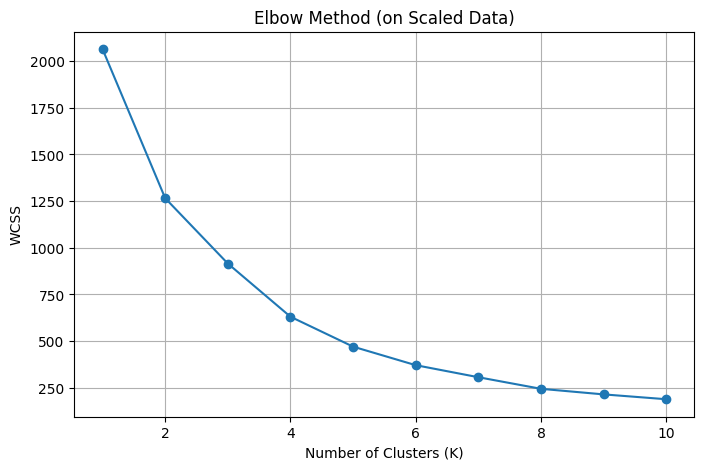

In [39]:
wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    # Fit KMeans on the scaled data
    km.fit(data_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method (on Scaled Data)")
plt.grid(True)
plt.show()

In [47]:
model = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10 # Added n_init to match elbow method and suppress future warning
)

# Fit KMeans on the scaled data
model.fit(data_scaled)

clusters = model.labels_
centroids_scaled = model.cluster_centers_

In [48]:
data['cluster'] = clusters
display(data.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,39.10000,18.70000,181.00000,3750.000000,2,0
1,39.50000,17.40000,186.00000,3800.000000,1,0
2,40.30000,18.00000,195.00000,3250.000000,1,0
3,43.92193,17.15117,214.01462,4201.754386,3,0
4,36.70000,19.30000,193.00000,3450.000000,1,0


In [49]:
display(data['cluster'].value_counts().sort_index())

,count
cluster,
0,219
1,124
2,1


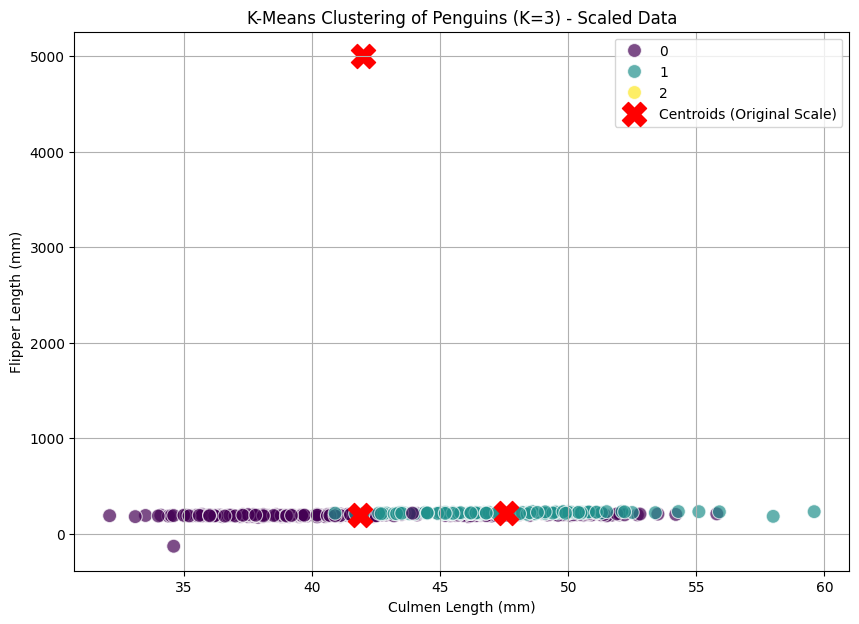

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

data['cluster'] = clusters

# Inverse transform the centroids to original scale for plotting
centroids_original_scale = scaler.inverse_transform(centroids_scaled)
# Use columns from data_scaled (which are the original features) to create centroids_df
centroids_df = pd.DataFrame(centroids_original_scale, columns=data_scaled.columns)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=data['culmen_length_mm'],
    y=data['flipper_length_mm'],
    hue=data['cluster'],
    palette='viridis',
    s=100, # size of points
    alpha=0.7,
    legend='full'
)

# Plot centroids in original scale
plt.scatter(
    centroids_df['culmen_length_mm'],
    centroids_df['flipper_length_mm'],
    marker='X',
    s=300, # size of centroids
    color='red',
    label='Centroids (Original Scale)'
)

plt.title('K-Means Clustering of Penguins (K=3) - Scaled Data')
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.legend()
plt.grid(True)
plt.show()